# Comparative Habitability Index of Solar System Worlds 

In [2]:
import pandas as pd 
import numpy as np 

In [3]:
data = {
    'world': ['Earth','Mars','Europa','Ganymede','Enceladus','Titan','Ceres','Triton','Pluto','Callisto'],

    #physical props
    'radius_km': [6371, 3389, 1560, 2634, 252, 2575, 473, 1353, 1188, 2410],
    'gravity': [9.81, 3.71, 1.31, 1.43, 0.113, 1.35, 0.27, 0.78, 0.62, 1.24],
    'surface_temp_k': [288, 210, 102, 110, 75, 94, 167, 38, 44, 134], 

    #water/solvent system 
    'subsurface_ocean': [1, 0, 1, 1, 1, 1, 1, 1, 0, 1],
    'surface_ocean': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
    'hydrocarbon_liquids': [0, 0, 0, 0, 0, 1, 0, 0, 0, 0], 

    #energy sources 
    'solar_flux_relative': [1.0, 0.43, 0.04, 0.03, 0.01, 0.01, 0.13, 0.001, 0.0006, 0.03],
    'tidal_heating': [0.05, 0.1, 0.9, 0.5, 0.8, 0.6, 0.1, 0.4, 0.1, 0.2],
    'radiogenic_heating': [0.8, 0.4, 0.6, 0.7, 0.5, 0.7, 0.4, 0.3, 0.2, 0.6], 

    #chemistry 
    'organic_complexity': [5, 2, 3, 3, 4, 5, 2, 3, 3, 2], 
   'redox_disequilibrium' : [5, 2, 5, 4, 5, 3, 1, 2, 1, 3], 

    #geophysical activity 
    'tectonics': [1, 0, 1, 1, 1, 0, 0, 1, 0, 0], 
    'hydrothermal_activity': [1, 0, 1, 1, 1, 1, 0, 1, 0, 1], 
}

df = pd.DataFrame(data)
df

,world,radius_km,gravity,surface_temp_k,subsurface_ocean,surface_ocean,hydrocarbon_liquids,solar_flux_relative,tidal_heating,radiogenic_heating,organic_complexity,redox_disequilibrium,tectonics,hydrothermal_activity
0,Earth,6371,9.810,288,1,1,0,1.0000,0.05,0.8,5,5,1,1
1,Mars,3389,3.710,210,0,0,0,0.4300,0.10,0.4,2,2,0,0
2,Europa,1560,1.310,102,1,0,0,0.0400,0.90,0.6,3,5,1,1
3,Ganymede,2634,1.430,110,1,0,0,0.0300,0.50,0.7,3,4,1,1
4,Enceladus,252,0.113,75,1,0,0,0.0100,0.80,0.5,4,5,1,1
5,Titan,2575,1.350,94,1,0,1,0.0100,0.60,0.7,5,3,0,1
6,Ceres,473,0.270,167,1,0,0,0.1300,0.10,0.4,2,1,0,0
7,Triton,1353,0.780,38,1,0,0,0.0010,0.40,0.3,3,2,1,1
8,Pluto,1188,0.620,44,0,0,0,0.0006,0.10,0.2,3,1,0,0
9,Callisto,2410,1.240,134,1,0,0,0.0300,0.20,0.6,2,3,0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   world                  10 non-null     object 
 1   radius_km              10 non-null     int64  
 2   gravity                10 non-null     float64
 3   surface_temp_k         10 non-null     int64  
 4   subsurface_ocean       10 non-null     int64  
 5   surface_ocean          10 non-null     int64  
 6   hydrocarbon_liquids    10 non-null     int64  
 7   solar_flux_relative    10 non-null     float64
 8   tidal_heating          10 non-null     float64
 9   radiogenic_heating     10 non-null     float64
 10  organic_complexity     10 non-null     int64  
 11  redox_disequilibrium   10 non-null     int64  
 12  tectonics              10 non-null     int64  
 13  hydrothermal_activity  10 non-null     int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.2+ KB


In [5]:
df.describe()

,radius_km,gravity,surface_temp_k,subsurface_ocean,surface_ocean,hydrocarbon_liquids,solar_flux_relative,tidal_heating,radiogenic_heating,organic_complexity,redox_disequilibrium,tectonics,hydrothermal_activity
count,10.000000,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,2220.500000,2.063300,126.20000,0.800000,0.100000,0.100000,0.168160,0.375000,0.520000,3.200000,3.100000,0.500000,0.700000
std,1767.239734,2.898806,77.43786,0.421637,0.316228,0.316228,0.320178,0.313803,0.193218,1.135292,1.595131,0.527046,0.483046
min,252.000000,0.113000,38.00000,0.000000,0.000000,0.000000,0.000600,0.050000,0.200000,2.000000,1.000000,0.000000,0.000000
25%,1229.250000,0.660000,79.75000,1.000000,0.000000,0.000000,0.010000,0.100000,0.400000,2.250000,2.000000,0.000000,0.250000
50%,1985.000000,1.275000,106.00000,1.000000,0.000000,0.000000,0.030000,0.300000,0.550000,3.000000,3.000000,0.500000,1.000000
75%,2619.250000,1.410000,158.75000,1.000000,0.000000,0.000000,0.107500,0.575000,0.675000,3.750000,4.750000,1.000000,1.000000
max,6371.000000,9.810000,288.00000,1.000000,1.000000,1.000000,1.000000,0.900000,0.800000,5.000000,5.000000,1.000000,1.000000


# Normalization 

In [7]:
df_norm= df.copy()

In [8]:
# Temperature 
# Gaussian centered on 275K; sigma=100 is generous to cold subsurface worlds
df_norm['temp_norm'] = np.exp(-((df_norm['surface_temp_k'] - 275)**2) / (2 * 100**2))

In [9]:
# Liquid solvent 
df_norm['solvent_score'] = (
    1.0 * df_norm['subsurface_ocean'] +
    0.9 * df_norm['surface_ocean'] +
    0.5 * df_norm['hydrocarbon_liquids']
)
df_norm['solvent_norm'] =df_norm['solvent_score'] / 2.4

In [10]:
# Energy source 
df_norm['solar_norm'] = df_norm['solar_flux_relative'] / df_norm['solar_flux_relative'].max()

# tidal upweighted over radiogenic: more dynamic, directly drives liquid water
df_norm['internal_energy'] = (
    0.6 * df_norm['tidal_heating'] + 0.4 * df_norm['radiogenic_heating']
) 

# internal energy upweighted: subsurface framing deprioritises solar flux
df_norm['energy_norm']= (
    0.3 * df_norm['solar_norm'] + 0.7 * df_norm['internal_energy']
)

In [11]:
# Chemistry
df_norm['organic_norm'] = df_norm['organic_complexity'] / 5
df_norm['redox_norm'] = df_norm['redox_disequilibrium'] / 5

df_norm['chemistry_norm'] = (
    df_norm['organic_norm'] + df_norm['redox_norm']
) / 2

In [12]:
# geophysical activity 

df_norm['geo_activity_raw'] = (
    df_norm['tectonics'] + df_norm['hydrothermal_activity']
)

df_norm['geo_norm'] = df_norm['geo_activity_raw']/ 2

In [13]:
norm_cols = [
    'temp_norm', 'solvent_norm', 'energy_norm',
    'chemistry_norm', 'geo_norm'
]

print("\nOut-of-range values present:",
      ((df_norm[norm_cols] < 0) | (df_norm[norm_cols] > 1)).any().any())


Out-of-range values present: False


In [14]:
print(df_norm[['world', 'temp_norm', 'solvent_norm', 'energy_norm',
               'chemistry_norm', 'geo_norm']].round(3).to_string(index=False))

    world  temp_norm  solvent_norm  energy_norm  chemistry_norm  geo_norm
    Earth      0.992         0.792        0.545             1.0       1.0
     Mars      0.810         0.000        0.283             0.4       0.0
   Europa      0.224         0.417        0.558             0.8       1.0
 Ganymede      0.256         0.417        0.415             0.7       1.0
Enceladus      0.135         0.417        0.479             0.9       1.0
    Titan      0.194         0.625        0.451             0.8       0.5
    Ceres      0.558         0.417        0.193             0.3       0.0
   Triton      0.060         0.417        0.252             0.5       1.0
    Pluto      0.069         0.000        0.098             0.4       0.0
 Callisto      0.370         0.417        0.261             0.5       0.5






# Habitability Index

In [16]:
df_norm['habitability_index'] = (
    0.30 * df_norm['solvent_norm'] +
    0.25 * df_norm['energy_norm'] + 
    0.20 * df_norm['chemistry_norm'] + 
    0.15 * df_norm['geo_norm'] + 
    0.10 * df_norm['temp_norm']
)

In [17]:
results = df_norm[['world', 'habitability_index']].sort_values(by= 'habitability_index', ascending=False
).reset_index(drop=True)

results.index += 1  # start ranking from 1
print(results.round(3).to_string())

        world  habitability_index
1       Earth               0.823
2      Europa               0.597
3   Enceladus               0.588
4       Titan               0.555
5    Ganymede               0.544
6      Triton               0.444
7    Callisto               0.402
8       Ceres               0.289
9        Mars               0.232
10      Pluto               0.111


# Visualization 

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

In [49]:
# Theme
BG, PANEL,ACCENT, GRID, TEXT, SUBTEXT = "#0A0E1A", "#111827", "#4FC3F7", "#1E2A3A", "#E2E8F0", "#64748B"

# Planetary color palette
WORLD_COLORS = { 'Earth': '#2E86AB', 'Europa':'#A8DADC', 'Enceladus':'#C8E6C9', 'Titan':'#FFB347',
                'Ganymede': '#B0BEC5','Triton': '#CE93D8', 'Callisto': '#8D6E63','Ceres': '#78909C',
                'Mars': '#EF5350','Pluto' : '#546E7A',}

plt.rcParams.update({'figure.facecolor' : BG, 'axes.facecolor': PANEL, 'axes.edgecolor': GRID, 'axes.labelcolor': TEXT,
                     'axes.titlecolor': TEXT, 'xtick.color': SUBTEXT, 'ytick.color': SUBTEXT, 'text.color': TEXT, 'grid.color': GRID,
                     'grid.linewidth': 0.6, 'font.family': 'DejaVu Sans', 'axes.spines.top': False, 'axes.spines.right' : False
                    })

In [21]:
def plot_bar(df_norm):
    data = (df_norm[['world', 'habitability_index']].sort_values(by= 'habitability_index', ascending=True))

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor(BG)

    colors = [WORLD_COLORS[w] for w in data['world']]

    bars = ax.barh(
        data['world'], data['habitability_index'],
        color=colors, height=0.6,
        edgecolor='none', zorder=3
    )

    # value labels
    for bar, val in zip(bars, data['habitability_index']):
        ax.text(
            val + 0.008, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left',
            fontsize=9.5, color=TEXT, fontweight='500'
        )

    # tier demarcation lines
    for x, label in [(0.55, 'Tier A'), (0.40, 'Tier B'), (0.28, 'Tier C')]:
        ax.axvline(x, color=ACCENT, linewidth=0.7, linestyle='--', alpha=0.4, zorder=2)
        ax.text(x + 0.005, 0.15, label, color=ACCENT, fontsize=7.5,
                alpha=0.6, transform=ax.get_xaxis_transform())

    ax.set_xlim(0, 1.0)
    ax.set_xlabel('Habitability Index Score', fontsize=11, labelpad=10)
    ax.set_title('Comparative Habitability Index\nof Solar System Worlds',
                 fontsize=14, fontweight='bold', pad=20, color=TEXT)

    subtitle = 'Astrobiological interest scored across solvent systems, energy, chemistry & geophysical activity'
    ax.text(0.5, 1.02, subtitle, transform=ax.transAxes,
            ha='center', fontsize=8.5, color=SUBTEXT)

    ax.grid(axis='x', zorder=1)
    ax.set_axisbelow(True)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)

    plt.tight_layout()
    plt.savefig('habitability_bar_chart.png', dpi=150,
                bbox_inches='tight', facecolor=BG)
    plt.show()
    print("Saved: habitability_bar_chart.png")

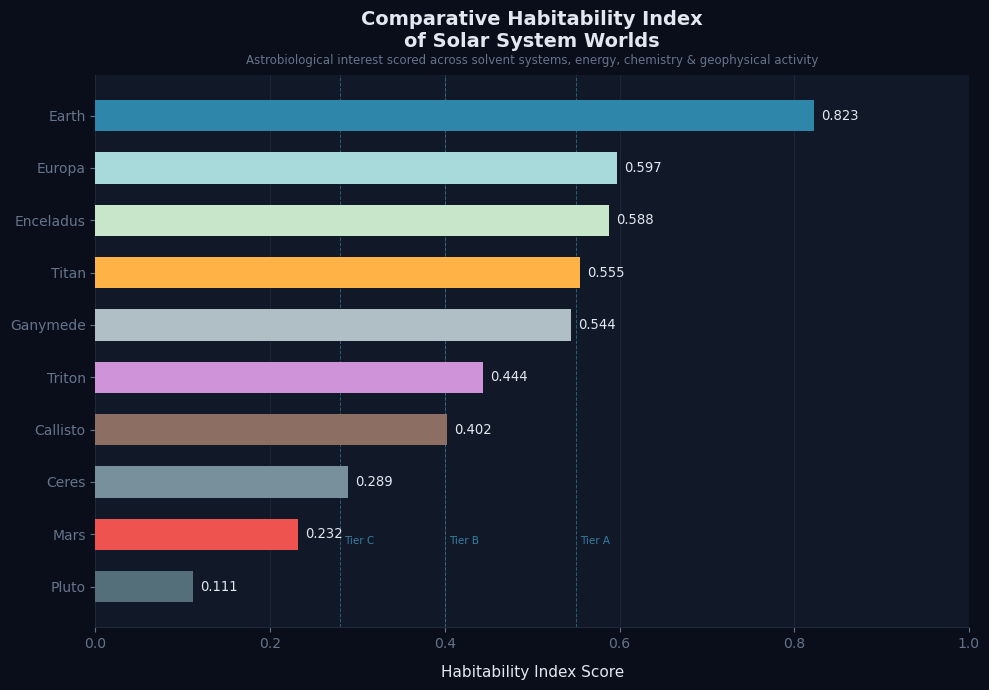

Saved: habitability_bar_chart.png


In [22]:
plot_bar(df_norm)

In [23]:
def plot_radar(df_norm):
    dims   = ['solvent_norm', 'energy_norm', 'chemistry_norm', 'geo_norm', 'temp_norm']
    labels = ['Solvent\nSystems', 'Energy\nSources', 'Chemistry','Geo\nActivity', 'Temperature']

    # highlight these worlds: most scientifically interesting spread
    worlds  = ['Earth', 'Europa', 'Enceladus', 'Titan', 'Mars']
    N       = len(dims)
    angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]   # close the polygon

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(PANEL)

    # grid rings
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=7, color=SUBTEXT)
    ax.yaxis.grid(True, color=GRID, linewidth=0.6)
    ax.xaxis.grid(True, color=GRID, linewidth=0.6)
    ax.spines['polar'].set_color(GRID)

    # axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10, color=TEXT)

    # plot each world
    for world in worlds:
        row    = df_norm[df_norm['world'] == world].iloc[0]
        values = [row[d] for d in dims]
        values += values[:1]
        color  = WORLD_COLORS[world]
        ax.plot(angles, values, color=color, linewidth=2, zorder=4)
        ax.fill(angles, values, color=color, alpha=0.08, zorder=3)
        # dot on each vertex
        ax.scatter(angles[:-1], values[:-1],
                   color=color, s=40, zorder=5, edgecolors='none')

    # legend
    handles = [mpatches.Patch(color=WORLD_COLORS[w], label=w) for w in worlds]
    ax.legend(handles=handles, loc='upper right',
              bbox_to_anchor=(1.35, 1.15),
              frameon=False, fontsize=9.5,
              labelcolor=TEXT)

    ax.set_title('Multi-Dimensional Habitability Profile',
                 fontsize=14, fontweight='bold',
                 pad=30, color=TEXT)
    subtitle = 'Normalized scores across five astrobiological dimensions'
    fig.text(0.5, 0.02, subtitle, ha='center', fontsize=8.5, color=SUBTEXT)

    plt.tight_layout()
    plt.savefig('habitability_radar_chart.png', dpi=150,
                bbox_inches='tight', facecolor=BG)
    plt.show()
    print("Saved: habitability_radar_chart.png")

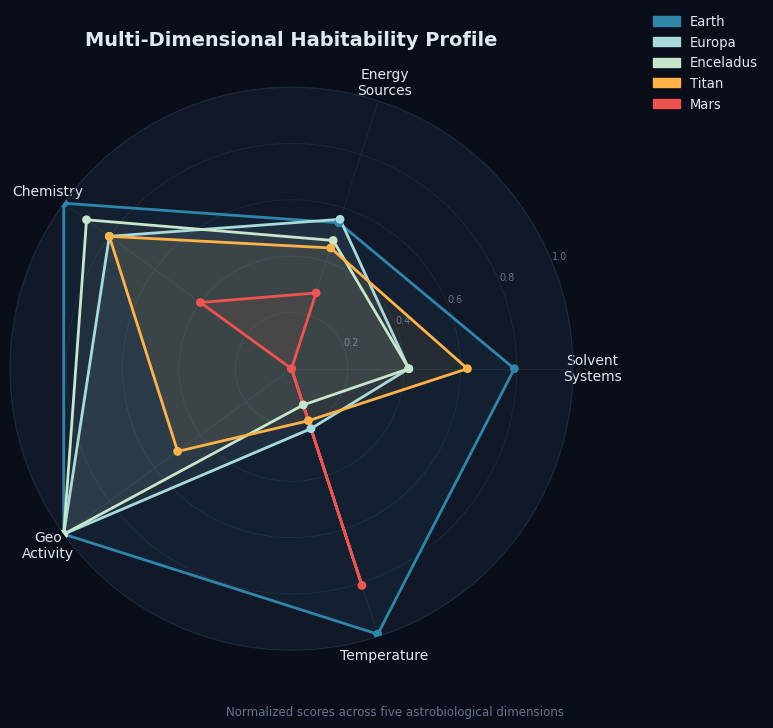

Saved: habitability_radar_chart.png


In [24]:
plot_radar(df_norm)

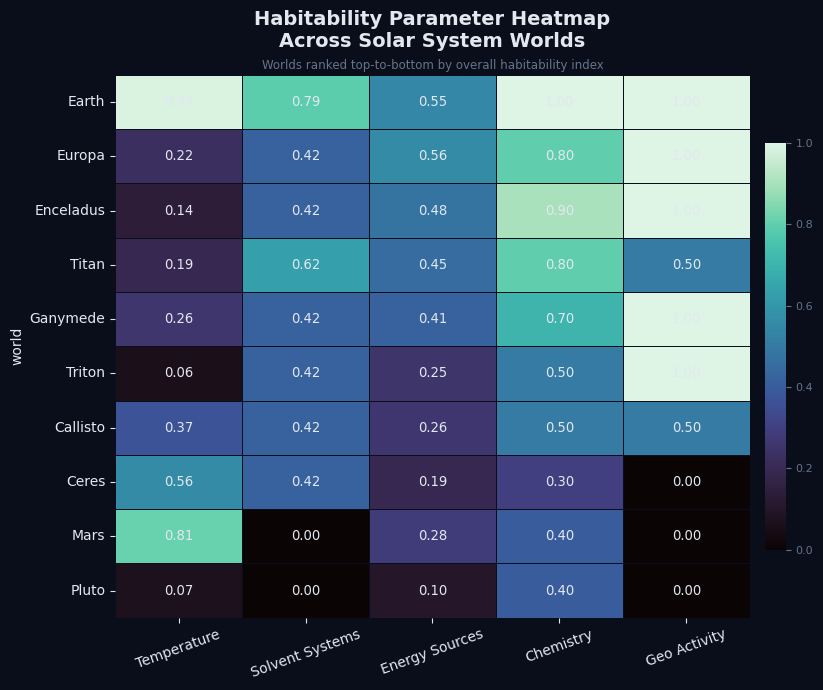

Saved: habitability_heatmap.png


In [25]:
def plot_heatmap(df_norm):
    dims = {'temp_norm': 'Temperature', 'solvent_norm': 'Solvent Systems','energy_norm': 'Energy Sources',
            'chemistry_norm': 'Chemistry', 'geo_norm': 'Geo Activity',
           }

    # order worlds by habitability index
    ordered = (df_norm.sort_values('habitability_index', ascending=False)
                      ['world'].tolist())

    matrix = (df_norm.set_index('world')
                     .loc[ordered, list(dims.keys())]
                     .rename(columns=dims))

    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(PANEL)

    cmap = sns.color_palette("mako", as_cmap=True)

    sns.heatmap(matrix, ax=ax, cmap=cmap, annot=True, fmt='.2f',
                annot_kws={'size': 9.5, 'color': TEXT}, linewidths=0.5, linecolor=BG,
                cbar_kws={'shrink': 0.75, 'pad': 0.02}, vmin=0, vmax=1,
               )

    # colorbar styling
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.set_tick_params(color=SUBTEXT)
    cbar.ax.tick_params(labelsize=8, colors=SUBTEXT)
    cbar.outline.set_edgecolor(GRID)

    ax.set_title('Habitability Parameter Heatmap\nAcross Solar System Worlds',
                 fontsize=14, fontweight='bold', pad=20, color=TEXT)
    subtitle = 'Worlds ranked top-to-bottom by overall habitability index'
    ax.text(0.5, 1.01, subtitle, transform=ax.transAxes,
            ha='center', fontsize=8.5, color=SUBTEXT)

    ax.tick_params(axis='x', colors=TEXT, labelsize=10, rotation=20)
    ax.tick_params(axis='y', colors=TEXT, labelsize=10, rotation=0)

    plt.tight_layout()
    plt.savefig('habitability_heatmap.png', dpi=150,
                bbox_inches='tight', facecolor=BG)
    plt.show()
    print("Saved: habitability_heatmap.png")

plot_heatmap(df_norm)